# Week 1 · Task 3 — Matrix multiplication: loops vs NumPy

**Roadmap task:** *Write matrix multiplication yourself with loops, then rewrite it in NumPy. Time both. Record the ratio — that is your first lesson in why vectorisation matters.*

**What this notebook shows**

1. The rule for multiplying matrices, and **why** it is that rule (composition of two transformations).
2. A triple-loop implementation, checked against NumPy.
3. A timing experiment: pure Python loops vs one-loop-plus-NumPy vs full NumPy.
4. The recorded speed ratio, and why it is so large.

In [1]:
import sys, pathlib, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # lets us `import mathkit` from the parent folder

import numpy as np
import matplotlib.pyplot as plt
from mathkit.linalg import matmul_loops, matmul_row_dot

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(suppress=True, precision=4)

## 1. The idea first — a matrix is a machine

The columns of a matrix tell you **where the basis vectors land**. For a 2×2 matrix

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}: \qquad \hat\imath \mapsto \begin{bmatrix} a \\ c \end{bmatrix}, \quad \hat\jmath \mapsto \begin{bmatrix} b \\ d \end{bmatrix}$$

So $A\vec x = x_1 \cdot(\text{column 1}) + x_2 \cdot(\text{column 2})$ — the input's coordinates say *how much of each landed basis vector to add*.

**Multiplying $AB$ means "do $B$ first, then $A$".** Column $j$ of $AB$ is where $A$ sends column $j$ of $B$:

$$(AB)_{:,j} = A\,(B_{:,j}) \quad\Longrightarrow\quad (AB)_{ij} = \sum_k A_{ik}\,B_{kj}$$

That sum is the "row times column" rule you memorised in school. It is not an arbitrary rule — it is **forced** by the requirement that $(AB)\vec x = A(B\vec x)$.

Let's *see* it: a shear, then a rotation.

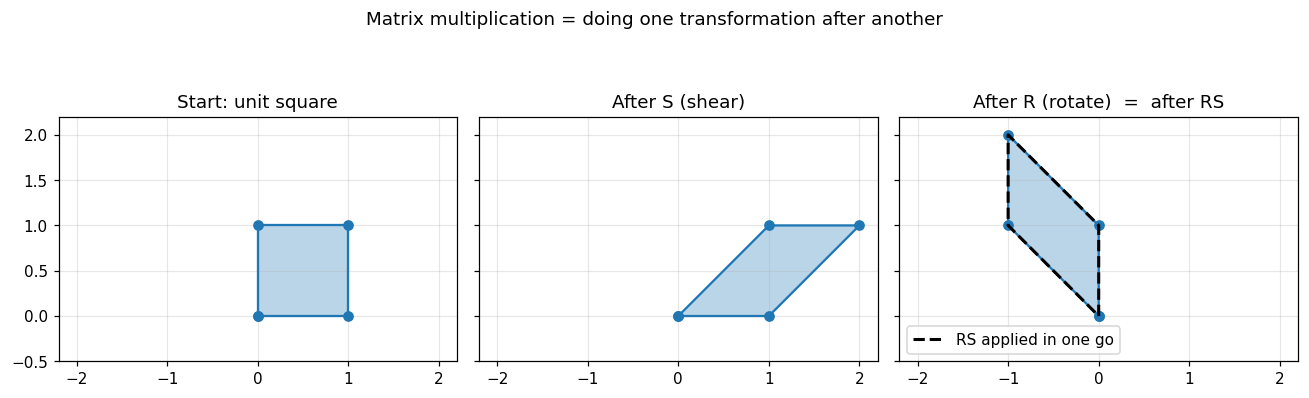

R @ S =
 [[ 0. -1.]
 [ 1.  1.]]
S @ R =
 [[ 1. -1.]
 [ 1.  0.]] 
-> different! Order matters: AB != BA in general.
(RS)x == R(Sx) for the square's corners? True


In [2]:
theta = np.pi / 2
R = np.array([[np.cos(theta), -np.sin(theta)],      # rotate 90° counter-clockwise
              [np.sin(theta),  np.cos(theta)]])
S = np.array([[1.0, 1.0],                            # shear: î stays, ĵ leans right
              [0.0, 1.0]])

square = np.array([[0, 1, 1, 0, 0],                  # unit square, as column vectors
                   [0, 0, 1, 1, 0]], dtype=float)

step1 = S @ square          # apply the shear
step2 = R @ step1           # then apply the rotation
RS = np.array(matmul_loops(R, S))
combined = RS @ square      # one matrix that does both

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, pts, title in zip(axes,
                          [square, step1, step2],
                          ["Start: unit square", "After S (shear)", "After R (rotate)  =  after RS"]):
    ax.fill(pts[0], pts[1], alpha=0.3)
    ax.plot(pts[0], pts[1], "o-")
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xlim(-2.2, 2.2); ax.set_ylim(-0.5, 2.2)
axes[2].plot(combined[0], combined[1], "k--", lw=2, label="RS applied in one go")
axes[2].legend(loc="lower left")
fig.suptitle("Matrix multiplication = doing one transformation after another")
fig.tight_layout(); fig.savefig(FIG / "w1_composition.png", dpi=150); plt.show()

print("R @ S =\n", RS)
print("S @ R =\n", S @ R, "\n-> different! Order matters: AB != BA in general.")
print("(RS)x == R(Sx) for the square's corners?", np.allclose(combined, step2))

The dashed outline (one matrix $RS$) lands exactly on the two-step result. That is the whole meaning of matrix multiplication.

## 2. The loop implementation

`matmul_loops` in `mathkit/linalg.py` is literally the formula:

```python
for i in range(n):            # every row of A
    for j in range(p):        # every column of B
        total = 0.0
        for k in range(m):    # walk along the shared dimension
            total += A[i][k] * B[k][j]
        C[i][j] = total
```

For $n\times n$ matrices that is $n \cdot n \cdot n = n^3$ multiply-adds. First, correctness — it must agree with NumPy:

In [3]:
rng = np.random.default_rng(0)
for n, m, p in [(2, 3, 4), (10, 10, 10), (7, 1, 5)]:
    A, B = rng.normal(size=(n, m)), rng.normal(size=(m, p))
    diff = np.max(np.abs(np.array(matmul_loops(A, B)) - A @ B))
    print(f"{n}x{m} @ {m}x{p}:  max |loops - numpy| = {diff:.2e}")

# A hand-checkable 3x3 example (the kind Gate 1 asks you to do on paper)
A3 = [[1, 2, 0], [0, 1, 3], [4, 0, 1]]
B3 = [[2, 1, 0], [1, 0, 1], [0, 2, 1]]
print("\nA3 @ B3 by loops:", matmul_loops(A3, B3))
# e.g. entry (0,0) = row0·col0 = 1*2 + 2*1 + 0*0 = 4

2x3 @ 3x4:  max |loops - numpy| = 2.78e-17
10x10 @ 10x10:  max |loops - numpy| = 1.78e-15
7x1 @ 1x5:  max |loops - numpy| = 0.00e+00

A3 @ B3 by loops: [[4.0, 1.0, 2.0], [1.0, 6.0, 4.0], [8.0, 6.0, 1.0]]


## 3. Timing — three versions

| version | what runs in Python | what runs in compiled code |
|---|---|---|
| `matmul_loops` | all $n^3$ multiply-adds | nothing |
| `matmul_row_dot` | $n$ loop iterations | each row × matrix |
| `A @ B` (NumPy) | one function call | everything (optimised BLAS library) |

In [4]:
def best_time(fn, *args, repeats=3):
    """Run fn several times, return the fastest wall-clock time (least noisy)."""
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(*args); times.append(time.perf_counter() - t0)
    return min(times)

sizes = [8, 16, 32, 64, 128, 200]
results = []
for n in sizes:
    A, B = rng.normal(size=(n, n)), rng.normal(size=(n, n))
    A_list, B_list = A.tolist(), B.tolist()
    t_loop = best_time(matmul_loops, A_list, B_list, repeats=1 if n >= 128 else 3)
    t_row = best_time(matmul_row_dot, A, B)
    t_np = best_time(np.matmul, A, B, repeats=20)
    results.append((n, t_loop, t_row, t_np))
    print(f"n={n:4d}   loops {t_loop*1e3:10.2f} ms   row-dot {t_row*1e3:8.3f} ms   "
          f"numpy {t_np*1e3:8.4f} ms   ratio loops/numpy = {t_loop/t_np:>10,.0f}x")

res = np.array(results)

n=   8   loops       0.03 ms   row-dot    0.014 ms   numpy   0.0011 ms   ratio loops/numpy =         27x
n=  16   loops       0.22 ms   row-dot    0.029 ms   numpy   0.0017 ms   ratio loops/numpy =        126x
n=  32   loops       1.49 ms   row-dot    0.051 ms   numpy   0.0041 ms   ratio loops/numpy =        358x
n=  64   loops      11.63 ms   row-dot    0.139 ms   numpy   0.0109 ms   ratio loops/numpy =      1,070x
n= 128   loops      93.05 ms   row-dot    0.575 ms   numpy   0.0538 ms   ratio loops/numpy =      1,731x


n= 200   loops     405.36 ms   row-dot    2.054 ms   numpy   0.2108 ms   ratio loops/numpy =      1,923x


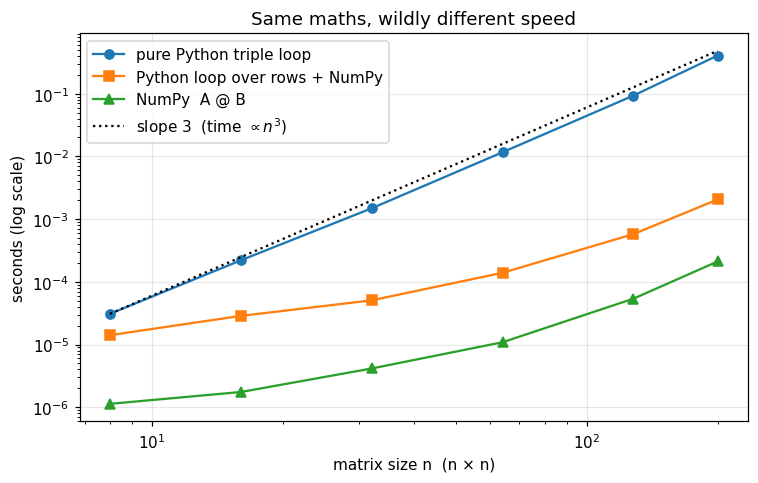

RECORDED RATIO at n=200: pure-Python loops are ~1,923x slower than NumPy.


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(res[:, 0], res[:, 1], "o-", label="pure Python triple loop")
ax.loglog(res[:, 0], res[:, 2], "s-", label="Python loop over rows + NumPy")
ax.loglog(res[:, 0], res[:, 3], "^-", label="NumPy  A @ B")
# reference slope-3 line: time ∝ n^3
ref = res[0, 1] * (res[:, 0] / res[0, 0]) ** 3
ax.loglog(res[:, 0], ref, "k:", label=r"slope 3  (time $\propto n^3$)")
ax.set_xlabel("matrix size n  (n × n)"); ax.set_ylabel("seconds (log scale)")
ax.set_title("Same maths, wildly different speed")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "w1_matmul_timing.png", dpi=150); plt.show()

n_big, t_loop_big, _, t_np_big = results[-1]
print(f"RECORDED RATIO at n={n_big}: pure-Python loops are ~{t_loop_big / t_np_big:,.0f}x slower than NumPy.")

## 4. What to notice (write this in your lab notebook)

* **The loop version follows the $n^3$ line.** Double $n$ → about 8× slower. That is the cost of the algorithm itself.
* **NumPy is thousands of times faster doing the *same* $n^3$ arithmetic.** Three reasons:
  1. *Interpreter overhead.* Every `total += A[i][k] * B[k][j]` in Python looks up types, creates new float objects, and checks bounds. Compiled code does none of that.
  2. *Memory layout.* NumPy arrays are one contiguous block of raw numbers, so the CPU cache is used efficiently. Python lists are arrays of pointers to objects scattered in memory.
  3. *BLAS.* `A @ B` calls a heavily optimised linear-algebra library that uses SIMD instructions (several multiplies per CPU instruction) and multiple cores.
* The middle version shows that **vectorising only the innermost loop already recovers most of the speed.** Rule for the rest of the year: *never write a Python loop over the elements of an array if an array operation exists.*

⚠️ **Your ratio will differ from mine** — it depends on your CPU and NumPy build. Re-run the timing cell on your own laptop and record *your* number.

## 5. Your turn (15–20 min)

1. On paper: multiply `A3 @ B3` above by hand and check it against the printed result.
2. Change the shear to `[[1, 0], [1, 1]]` and predict the picture before running the cell.
3. Show $AB \ne BA$ with two 2×2 matrices you invent, then find two that *do* commute (hint: try two rotations).
4. **Explain out loud (record it):** "Why is matrix multiplication defined as row-times-column?" — without notes, in under 60 seconds.